# **🚨Comment Toxicity**

# *Import Necessary Libraries*

In [1]:
# 📦 Data handling libraries
import pandas as pd              
import numpy as np               

# 📊 Visualization libraries
import matplotlib.pyplot as plt  
import seaborn as sns            

# 🔤 Text processing
import re                        

# ⚙️ Deep Learning - Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# 🔀 Train-Test Split
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report


# 🤖 Deep Learning - TensorFlow / Keras
import tensorflow as tf                              
from tensorflow.keras.models import Sequential       
from tensorflow.keras.layers import Embedding , LSTM  , Bidirectional     
from tensorflow.keras.layers import Conv1D           
from tensorflow.keras.layers import GlobalMaxPooling1D  
from tensorflow.keras.layers import Dense            
from tensorflow.keras.layers import Dropout      
import tensorflow as tf
   

# 🔢 Tokenization & Padding (for Neural Networks)
from tensorflow.keras.preprocessing.text import Tokenizer   
from tensorflow.keras.preprocessing.sequence import pad_sequences  

# 🧠 Natural Language Processing
import nltk                             
from nltk.corpus import stopwords        # Stopwords removal

# ⛔ Ignore warnings
import warnings
warnings.filterwarnings("ignore")        

# 📂 Load the train and  dataset

In [2]:
train_df = pd.read_csv('train.csv')
test_df =pd.read_csv('test.csv')
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [4]:
train_df.shape

(159571, 8)

In [5]:
test_df.shape

(153164, 2)

In [6]:
train_df.dtypes

id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

In [7]:
# dataset stats
train_df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [9]:
train_df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

# **Exploratory Data Analysis**

In [10]:
x = train_df.iloc[:, 2:].sum() # get total count of toxic labels 
x

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [11]:
rowsums = train_df.iloc[:, 2:].sum(axis=1) # take label row-wise and sum of label columns
rowsums

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [12]:
no_label_count = 0

for i, count in rowsums.items():
    if count==0:
        no_label_count += 1
        
print('Total number of comments:', len(train_df))
print('Total number of comments without labels:', no_label_count)
print('Total labels:', x.sum())

Total number of comments: 159571
Total number of comments without labels: 143346
Total labels: 35098


## **Label Counts**

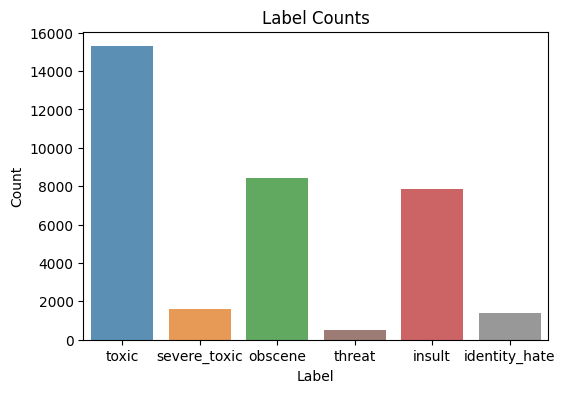

In [13]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=x.index, y=x.values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:brown', 'tab:red', 'tab:grey'])
plt.title('Label Counts')
plt.ylabel('Count')
plt.xlabel('Label')

plt.show()

## **Number of Labels per Comment**

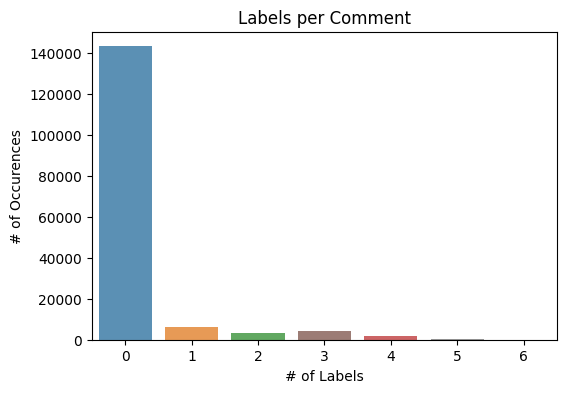

In [14]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=rowsums.values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:brown', 'tab:red', 'tab:grey'])
plt.title('Labels per Comment')
plt.ylabel('# of Occurences')
plt.xlabel('# of Labels')

plt.show()

# 🧹   **Data Prepocessing**

In [15]:
train_df = train_df.drop(columns=['id'], axis=1)
train_df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## **Cleaning**

In [16]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text 

In [17]:
# 1. Clean Training Data (Use train_df here)
train_df['comment_text'] = train_df['comment_text'].apply(lambda x: clean(x))
train_df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0
1,daww he matches this background colour im seem...,0,0,0,0,0,0
2,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [18]:
# 2. Clean Test Data (Use test_df here)
test_df['comment_text'] = test_df['comment_text'].apply(lambda x: clean(x))
test_df.head()

,id,comment_text
0,00001cee341fdb12,yo bitch ja rule is more succesful then youll ...
1,0000247867823ef7,from rfc the title is fine as it is imo
2,00013b17ad220c46,sources zawe ashton on lapland
3,00017563c3f7919a,if you have a look back at the source the info...
4,00017695ad8997eb,i dont anonymously edit articles at all


#  **Stopword Removal**

In [19]:
def remove_stopwords(text):

    stop_words = set(stopwords.words('english')) # Defined inside now!
    words = str(text).split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

In [20]:
train_df['comment_text'] = train_df['comment_text'].apply(clean)

In [21]:
train_df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0
1,daww he matches this background colour im seem...,0,0,0,0,0,0
2,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [22]:
test_df['comment_text'] = test_df['comment_text'].apply(clean)

In [23]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,yo bitch ja rule is more succesful then youll ...
1,0000247867823ef7,from rfc the title is fine as it is imo
2,00013b17ad220c46,sources zawe ashton on lapland
3,00017563c3f7919a,if you have a look back at the source the info...
4,00017695ad8997eb,i dont anonymously edit articles at all


In [24]:
initial_rows = train_df.shape[0] 
train_df.drop_duplicates(subset=['comment_text'], inplace=True) 
train_df.reset_index(drop=True, inplace=True) 

print(f"Duplicates Removed: {initial_rows - train_df.shape[0]}")

print(f"Final Train Shape: {train_df.shape}") 

Duplicates Removed: 1351
Final Train Shape: (158220, 7)


In [25]:
train_df.isnull().sum()

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [26]:
initial_shape_test = test_df.shape
test_df.drop_duplicates(subset=['comment_text'], inplace=True) 
test_df.reset_index(drop=True, inplace=True)

print(f"Duplicates Removed from Test: {initial_shape_test[0] - test_df.shape[0]}")


print(f"Final Test Shape: {test_df.shape}") 

Duplicates Removed from Test: 2362
Final Test Shape: (150802, 2)


# **Tokenization**

### Independent Variable (X) – Input

In [27]:
# 1. Tokenizer setup

MAX_WORDS = 20000
MAX_LEN = 150
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['comment_text'])


In [28]:
# 2. Convert to sequences & Apply Padding for Train

train_sequences = tokenizer.texts_to_sequences(train_df['comment_text'])
X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post')

In [29]:
# 3. Convert to sequences & Apply Padding for Test

test_sequences = tokenizer.texts_to_sequences(test_df['comment_text'])
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post')

In [30]:
print("✅ Tokenization and Padding Complete!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")

✅ Tokenization and Padding Complete!
X_train Shape: (158220, 150)
X_test Shape: (150802, 150)


#  **Prepare Target labels**

### Dependent Variable (y) – Output / Target

In [31]:
target_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
y_train = train_df[target_cols].values
print("Target labels y_train shape:", y_train.shape)

Target labels y_train shape: (158220, 6)


# **Train–Validation Data Split**

In [32]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print("Train:", X_tr.shape, y_tr.shape)
print("Val  :", X_val.shape, y_val.shape)

Train: (142398, 150) (142398, 6)
Val  : (15822, 150) (15822, 6)


# **CNN Model**

In [33]:
VOCAB_SIZE = MAX_WORDS   # ex: 20000
SEQ_LEN    = MAX_LEN     # ex: 150
EMB_DIM    = 128

cnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMB_DIM, input_length=SEQ_LEN),

    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(6, activation="sigmoid")   # 6 labels
])


In [34]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(curve="ROC", multi_label=True, name="auc")]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Model Train**

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1)
]

history = cnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    callbacks=callbacks
)


Epoch 1/5
 706/1113 ━━━━━━━━━━━━━━━━━━━━ 1:07 167ms/step - auc: 0.7807 - loss: 0.1348

# **Model Evaluation**

In [ ]:

val_probs = cnn_model.predict(X_val, batch_size=256)
val_pred  = (val_probs >= 0.5).astype(int)

print(classification_report(y_val, val_pred, target_names=target_cols, zero_division=0))

62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step
               precision    recall  f1-score   support

        toxic       0.86      0.69      0.76      1573
 severe_toxic       0.62      0.15      0.24       151
      obscene       0.89      0.70      0.78       882
       threat       0.00      0.00      0.00        46
       insult       0.77      0.55      0.64       783
identity_hate       0.58      0.39      0.46       124

    micro avg       0.83      0.62      0.71      3559
    macro avg       0.62      0.41      0.48      3559
 weighted avg       0.81      0.62      0.70      3559
  samples avg       0.06      0.06      0.06      3559



#  **Prediction**
### Predict toxicity for new comments.

In [ ]:
def predict_comment(text):
    # Preprocess
    text = clean(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    # Predict
    probs = cnn_model.predict(pad)[0]
    return dict(zip(target_cols, probs))

test_list = ["You are stupid and I hate you"]
for comment in test_list:
    result = predict_comment(comment)
    print(f"\n--- Result for: '{comment}' ---")
    for label, prob in result.items():
        # float(prob) helps to avoid formatting errors
        print(f"{label:15}: {float(prob):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

--- Result for: 'You are stupid and I hate you' ---
toxic          : 0.9774
severe_toxic   : 0.1014
obscene        : 0.6022
threat         : 0.0678
insult         : 0.7638
identity_hate  : 0.2069


# **LSTMs Model**

In [ ]:
VOCAB_SIZE = MAX_WORDS   # ex: 20000
SEQ_LEN    = MAX_LEN     # ex: 150
EMB_DIM    = 128

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMB_DIM, input_length=SEQ_LEN),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(6, activation="sigmoid")   # 6 labels
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(curve="ROC", multi_label=True, name="auc")]
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Model Train**

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1)
]

history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    callbacks=callbacks)


Epoch 1/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 279s 246ms/step - auc: 0.9211 - loss: 0.0727 - val_auc: 0.9562 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 2/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 259s 233ms/step - auc: 0.9610 - loss: 0.0485 - val_auc: 0.9601 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 3/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 260s 234ms/step - auc: 0.9683 - loss: 0.0434 - val_auc: 0.9660 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 4/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 269s 240ms/step - auc: 0.9798 - loss: 0.0374 - val_auc: 0.9583 - val_loss: 0.0539 - learning_rate: 5.0000e-04
Epoch 5/5
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 408s 317ms/step - auc: 0.9836 - loss: 0.0332 - val_auc: 0.9575 - val_loss: 0.0548 - learning_rate: 2.5000e-04


# **Model Evaluation**

In [ ]:

val_probs = lstm_model.predict(X_val, batch_size=256)
val_pred  = (val_probs >= 0.5).astype(int)

print(classification_report(y_val, val_pred, target_names=target_cols, zero_division=0))

62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step
               precision    recall  f1-score   support

        toxic       0.83      0.74      0.79      1573
 severe_toxic       0.47      0.29      0.36       151
      obscene       0.85      0.75      0.80       882
       threat       0.00      0.00      0.00        46
       insult       0.72      0.61      0.66       783
identity_hate       0.00      0.00      0.00       124

    micro avg       0.80      0.66      0.72      3559
    macro avg       0.48      0.40      0.43      3559
 weighted avg       0.76      0.66      0.71      3559
  samples avg       0.07      0.06      0.06      3559



#  **Prediction**
### Predict toxicity for new comments.

In [ ]:
def predict_comment(text):
    text = clean(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    
    # lstm_model-nu mathi check pannunga
    probs = lstm_model.predict(pad)[0] 
    
    return dict(zip(target_cols, probs))

In [ ]:
test_comments = ["You are a total idiot."]

for text in test_comments:
    print(f"\n--- Result for: '{text}' ---")
    res = predict_comment(text)
    
    for label, prob in res.items():
        val = float(prob) if not isinstance(prob, dict) else float(list(prob.values())[0])
        print(f"{label:15}: {val:.4f}")


--- Result for: 'You are a total idiot.' ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
toxic          : 0.9907
severe_toxic   : 0.0228
obscene        : 0.5274
threat         : 0.0090
insult         : 0.8961
identity_hate  : 0.0992


In [ ]:
from sklearn.metrics import roc_auc_score

# Predictions
cnn_auc = roc_auc_score(y_val, cnn_model.predict(X_val))
lstm_auc = roc_auc_score(y_val, lstm_model.predict(X_val))

print(f"📊 CNN Mean AUC  : {cnn_auc:.4f}")
print(f"📊 LSTM Mean AUC : {lstm_auc:.4f}")
print(f"🏆 Best Model: {'LSTM' if lstm_auc > cnn_auc else 'CNN'}")

495/495 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step
📊 CNN Mean AUC  : 0.9772
📊 LSTM Mean AUC : 0.9749
🏆 Best Model: CNN


In [ ]:
print("🏆 MODEL JUSTIFICATION")
print("-" * 30)
print("1. CNN  : Best for fast pattern matching (keywords).")
print("2. LSTM : Best for context & sequence understanding.")
print(f"\n✅ Best Model : {'LSTM' if lstm_auc > cnn_auc else 'CNN'} is chosen for higher accuracy.")

🏆 MODEL JUSTIFICATION
------------------------------
1. CNN  : Best for fast pattern matching (keywords).
2. LSTM : Best for context & sequence understanding.

✅ Best Model : CNN is chosen for higher accuracy.


In [ ]:
import os
import pickle

os.makedirs('models', exist_ok=True)

cnn_model.save('models/cnn_model.keras')

with open('models/tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("🚀 Model and Tokenizer saved successfully in 'models/' folder!")

🚀 Model and Tokenizer saved successfully in 'models/' folder!
